In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path
DATA_DIR = Path("../data")
list(DATA_DIR.iterdir())

[PosixPath('../data/weather_test.parquet'),
 PosixPath('../data/network_test.parquet'),
 PosixPath('../data/target_train.parquet'),
 PosixPath('../data/.gitkeep'),
 PosixPath('../data/weather_train.parquet'),
 PosixPath('../data/network_train.parquet')]

In [2]:
df_weather = pd.read_parquet(DATA_DIR / "weather_train.parquet")
df_network = pd.read_parquet(DATA_DIR / "network_train.parquet")
df_target = pd.read_parquet(DATA_DIR / "target_train.parquet")

<Axes: xlabel='start_date'>

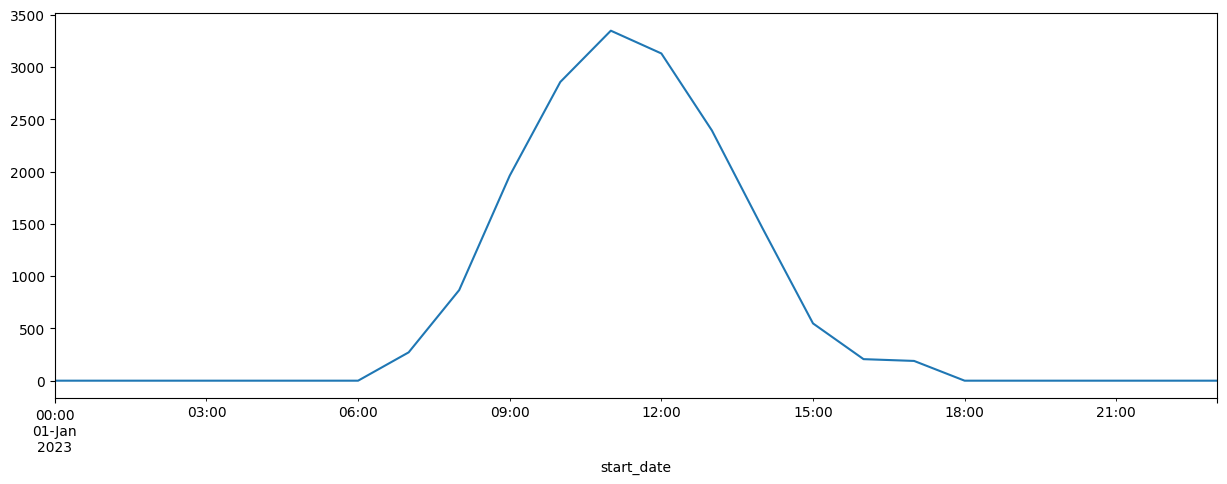

In [64]:
# print(df_target.columns)
df_target.loc["2023-01-01", 'FR_solar_actual'].plot(figsize=(15, 5))

In [15]:
# Start with electricity demand
df = df_target.copy()

In [51]:

def add_calendar_features(df):
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["dayofyear"] = df.index.dayofyear


    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    return df

In [ ]:
# Add calendar features
df = add_calendar_features(df)

# Add temperature features
df["temp_avg"] = df_weather[[
    col for col in df_weather.columns
    if col[2] == "2t"
]].mean(axis=1)



In [ ]:

wind_cols = [
    col for col in df_weather.columns
    if col[2] == "100ws"
]

sun_cols = [
    col for col in df_weather.columns
    if col[2] == "ssrd"
]

print("Wind cols:", len(wind_cols))
print("Sun cols:", len(sun_cols))


# -------------------------
# Aggregate wind and sun features
# -------------------------

df["wind_avg"] = df_weather[wind_cols].mean(axis=1)
df["sun_avg"] = df_weather[sun_cols].mean(axis=1)

df["wind_avg"] = (
    df["wind_avg"]
    .interpolate()
    .bfill()
)

df["sun_avg"] = (
    df["sun_avg"]
    .interpolate()
    .bfill()
)

Wind cols: 181
Sun cols: 268


In [235]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

MODEL = 'LGBMRegressor'

def forecast_model(df, FEATURES, TARGET):

    # Chronological train/validation split
    train = df.loc[df.index < "2024-01-01"].copy()
    valid = df.loc[df.index >= "2024-01-01"].copy()

    train = train.dropna(subset=[TARGET])
    valid = valid.dropna(subset=[TARGET])

    if MODEL == 'RandomForestRegressor':
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )

    elif MODEL == 'HistGradientBoostingRegressor':
        model = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42,
    )
        
    elif MODEL == 'LGBMRegressor':
        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
        )
        # model = LGBMRegressor(
        #     n_estimators=300,
        #     learning_rate=0.03,
        #     num_leaves=15,
        #     max_depth=5,
        #     min_child_samples=200,
        #     subsample=0.7,
        #     colsample_bytree=0.7,
        #     reg_alpha=1.0,
        #     reg_lambda=1.0,
        #     random_state=42,
        #     n_jobs=-1,
        # )

    model.fit(train[FEATURES], train[TARGET])

    # Predict
    train["pred"] = model.predict(train[FEATURES])
    valid["pred"] = model.predict(valid[FEATURES])


    # Evaluate
    mae = mean_absolute_error(valid[TARGET], valid["pred"])
    rmse = mean_squared_error(valid[TARGET], valid["pred"]) ** 0.5

    print(f"MAE:  {mae:,.2f} MW")
    print(f"RMSE: {rmse:,.2f} MW")

    return train, valid, model



There are four target variables that need to be predicted for the whole 2025.
I suspect that price is the most difficult to predict as it is affected by many parameters. So, I am leaving it for later.
I am starting with electricity load as, from inspection it exhibits strong seasonalities (at least annual and daily from directo visual inspection, but also suspect weekly)

Some design decisions that need to be made:
1. Could either decompose the load time series into seasonal components and model only the remaining time series or work on the initial time series by using lag features together with an ML model. I am choosing to do the second.
2. Could choose to do recursive or direct forecasting. As exogenous features are provided for the whole 2025 prediction period I am choosing to do the second.

MAE:  2,344.99 MW
RMSE: 3,095.31 MW


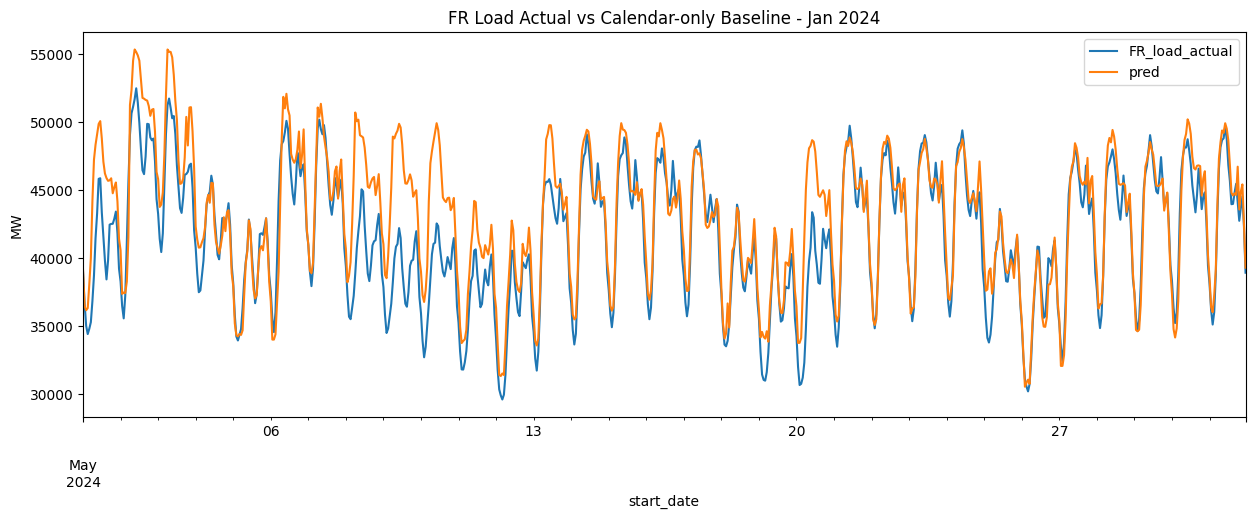

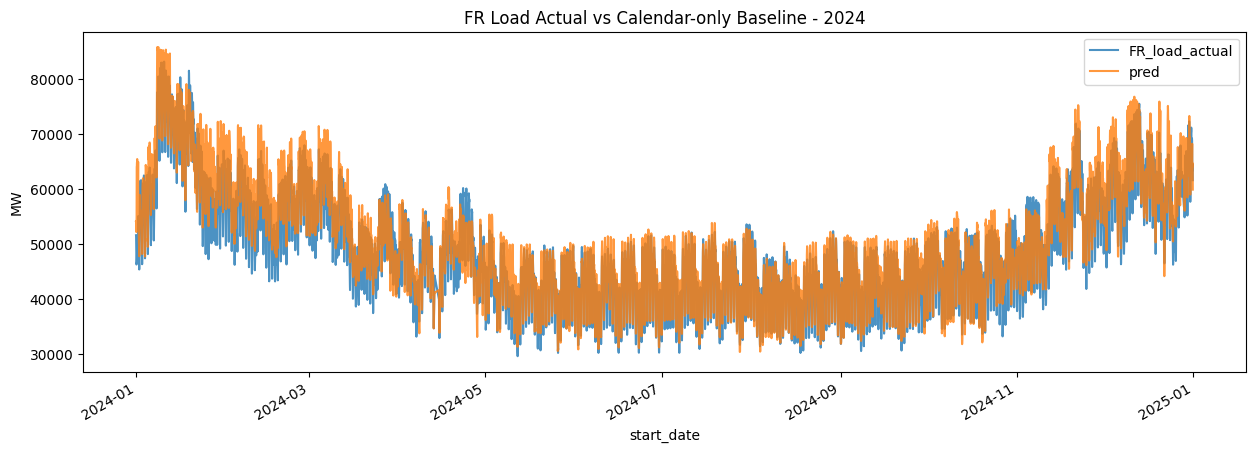

doy_cos     0.524826
doy_sin     0.147161
temp_avg    0.102867
hour_cos    0.099367
dow_sin     0.066814
hour_sin    0.054922
dow_cos     0.004043
dtype: float64

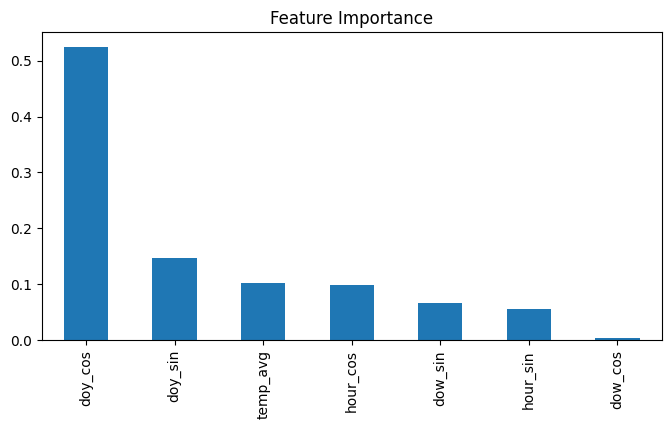

In [ ]:
# -------------------------
# 3. Define target and features
# -------------------------

TARGET = "FR_load_actual"

FEATURES = [
    "temp_avg",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
]


train, valid, model = forecast_model(df, FEATURES, TARGET)


# -------------------------
# 8. Plot one month
# -------------------------

valid.loc["2024-05", [TARGET, "pred"]].plot(figsize=(15, 5))
plt.title("FR Load Actual vs Calendar-only Baseline - Jan 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 9. Plot whole validation year
# -------------------------

valid[[TARGET, "pred"]].plot(figsize=(15, 5), alpha=0.8)
plt.title("FR Load Actual vs Calendar-only Baseline - 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 10. Feature importance
# -------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

display(feature_importance)

feature_importance.plot(kind="bar", figsize=(8, 4))
plt.title("Feature Importance")
plt.show()

<Axes: xlabel='start_date'>

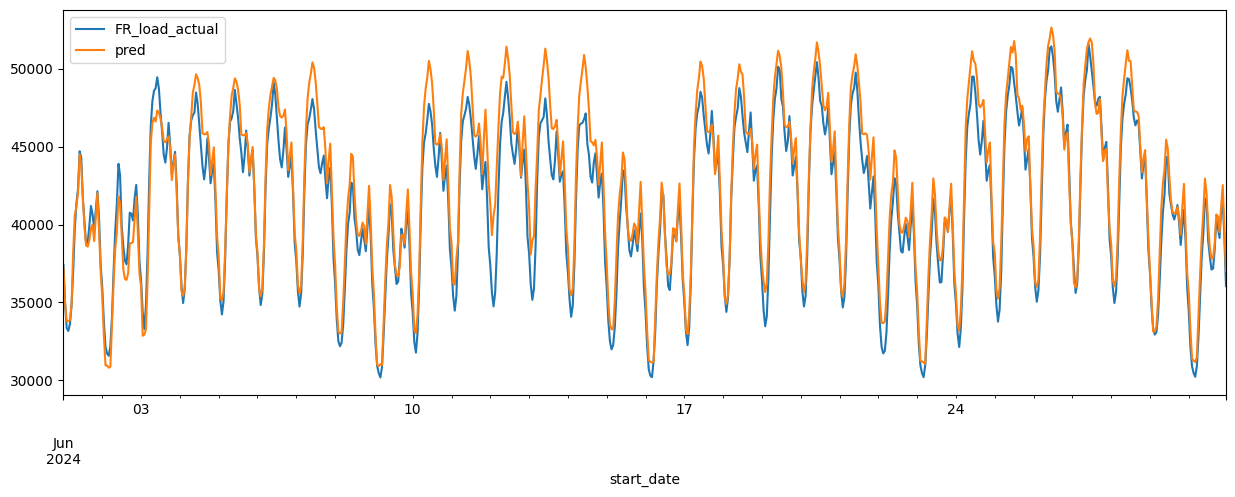

In [54]:
valid.loc["2024-06", ["FR_load_actual", "pred"]].plot(figsize=(15,5))

# MAE:  2,343.08 MW
# RMSE: 3,151.65 MW

<Axes: xlabel='start_date'>

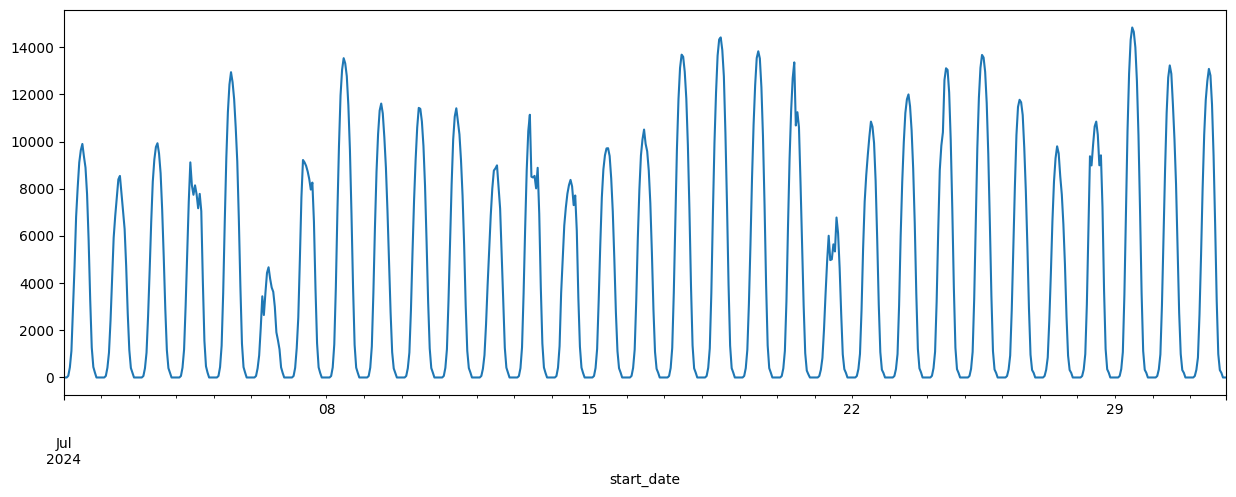

In [76]:
df_target.loc[df_target.FR_solar_actual.gt(20000), 'FR_solar_actual'] = np.nan
df_target['FR_solar_actual'] = df_target['FR_solar_actual'].ffill()
df_target.loc["2024-07", "FR_solar_actual"].plot(figsize=(15,5))

<Axes: xlabel='start_date'>

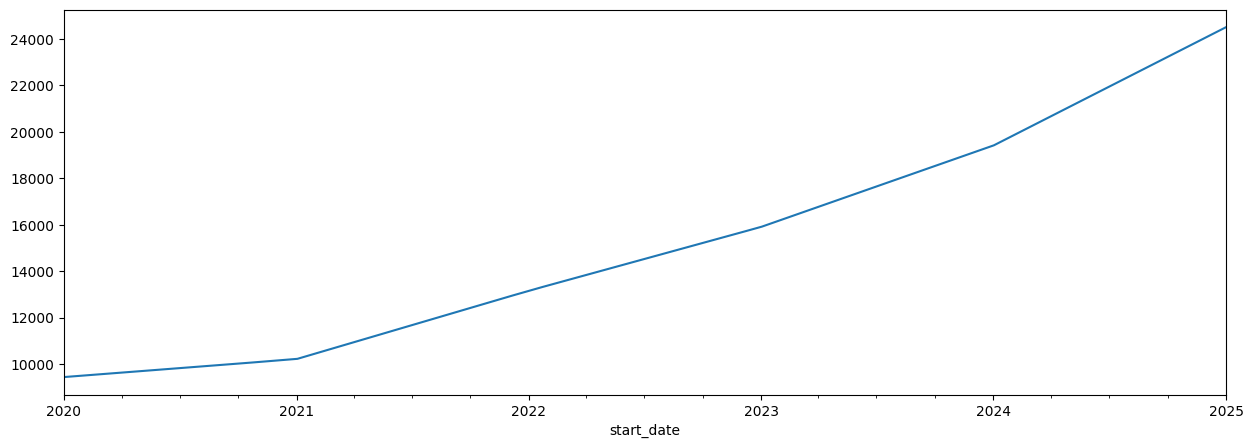

In [50]:
df_network.FR_capacity_solar.plot(figsize=(15,5))

MAE:  694.79 MW
RMSE: 1,085.24 MW


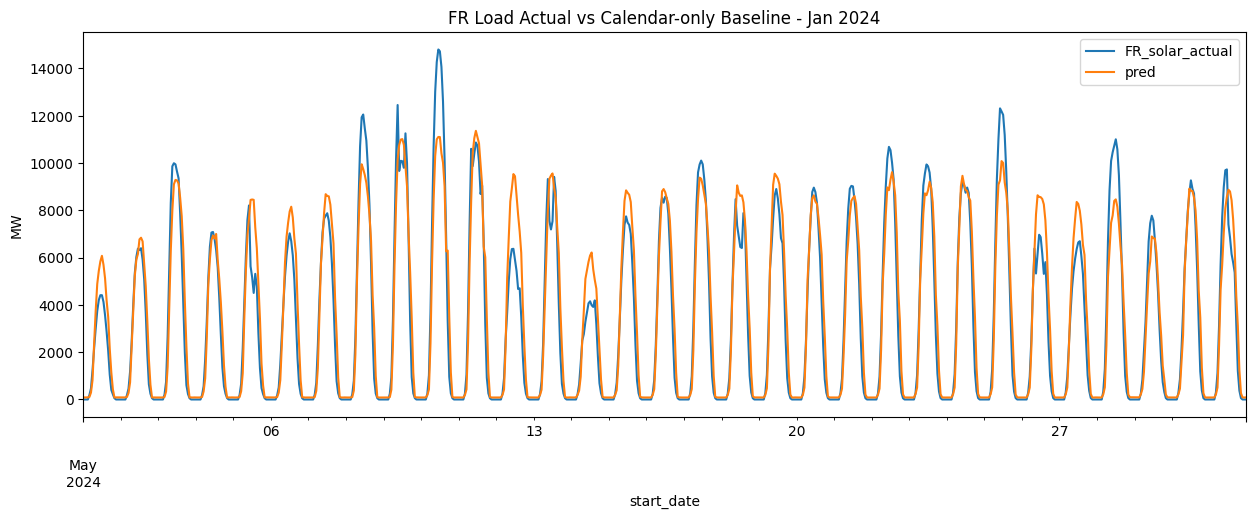

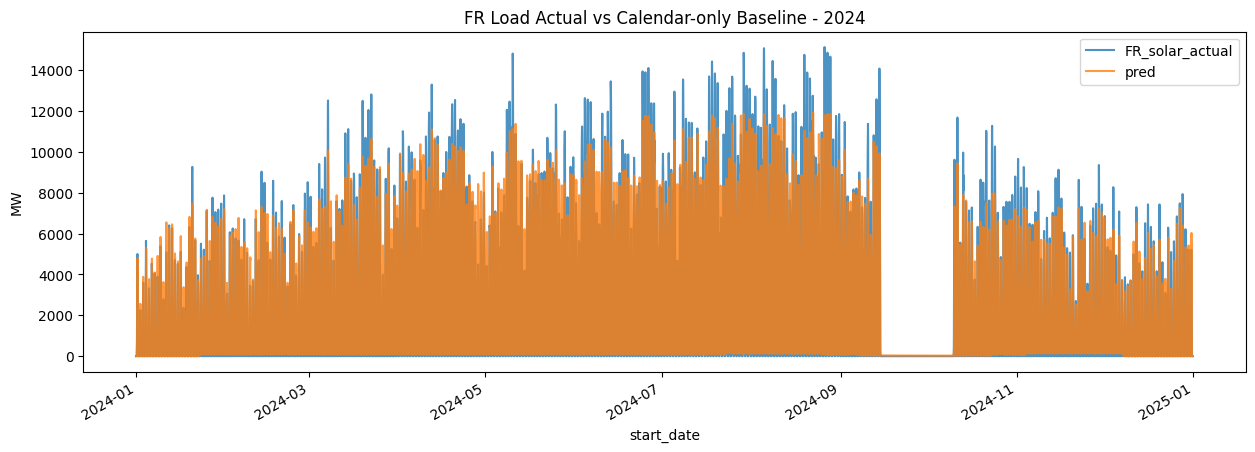

sun_avg              0.857069
hour_sin             0.059874
FR_capacity_solar    0.058036
tcc_avg              0.011950
hour_cos             0.006746
doy_cos              0.003167
doy_sin              0.003157
dtype: float64

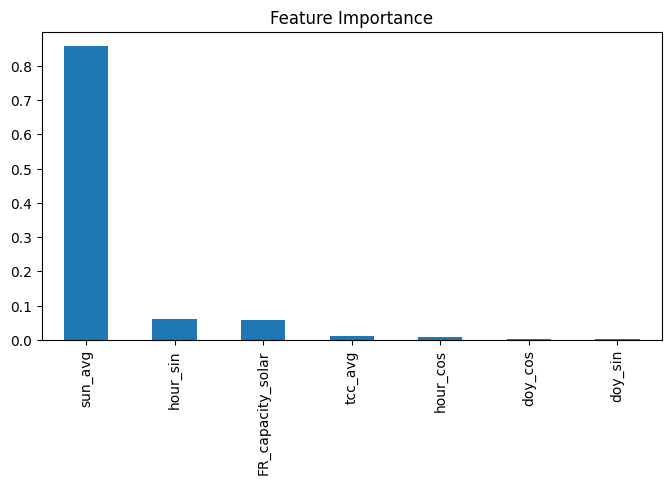

In [ ]:

df["FR_capacity_solar"] = df_network["FR_capacity_solar"]

sun_cols = [
    col for col in df_weather.columns
    if col[2] == "ssrd"
]

tcc_cols = [
    col for col in df_weather.columns
    if col[2] == "tcc"
]

df["sun_avg"] = df_weather[sun_cols].mean(axis=1)
df["tcc_avg"] = df_weather[tcc_cols].mean(axis=1)

df["sun_avg"] = df["sun_avg"].interpolate().bfill().ffill()
df["tcc_avg"] = df["tcc_avg"].interpolate().bfill().ffill()



TARGET = "FR_solar_actual"

FEATURES = [
    "FR_capacity_solar",
    "sun_avg",
    "tcc_avg",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]


train, valid, model = forecast_model(df, FEATURES, TARGET)

# -------------------------
# 8. Plot one month
# -------------------------

valid.loc["2024-05", [TARGET, "pred"]].plot(figsize=(15, 5))
plt.title("FR Load Actual vs Calendar-only Baseline - Jan 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 9. Plot whole validation year
# -------------------------

valid[[TARGET, "pred"]].plot(figsize=(15, 5), alpha=0.8)
plt.title("FR Load Actual vs Calendar-only Baseline - 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 10. Feature importance
# -------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

display(feature_importance)

feature_importance.plot(kind="bar", figsize=(8, 4))
plt.title("Feature Importance")
plt.show()


# MAE:  694.79 MW
# RMSE: 1,085.24 MW

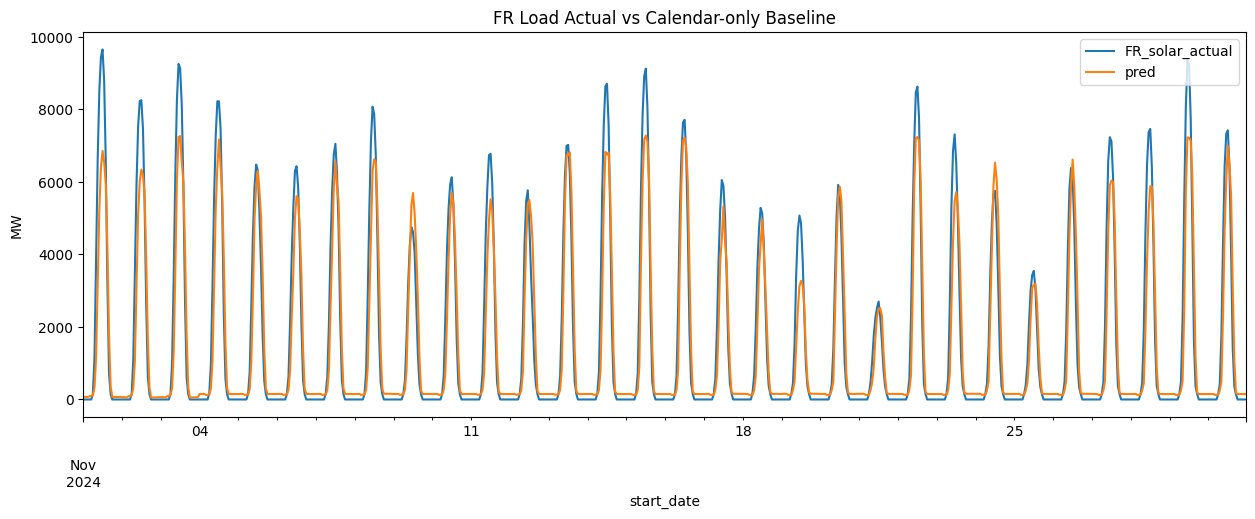

In [103]:
valid.loc["2024-11", [TARGET, "pred"]].plot(figsize=(15, 5))
plt.title("FR Load Actual vs Calendar-only Baseline")
plt.ylabel("MW")
plt.show()


<Axes: xlabel='start_date'>

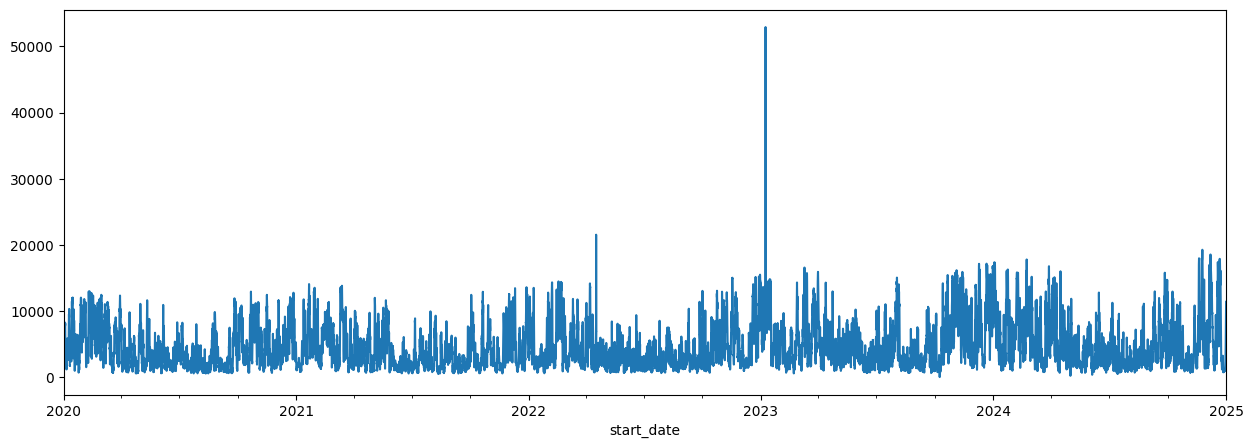

In [65]:
df.loc[:, "FR_wind_actual"].plot(figsize=(15,5))

In [126]:
"""
There are a few suspicious spikes in the wind as well as the solar data, likely due to measurement errors.
These are much larger than neighboring values.
I am using interpolation to replace them.
"""

series = df["FR_wind_actual"].copy()

def interpolate_spurious_values(series):

    prev_val = series.shift(1)
    next_val = series.shift(-1)

    ratio_limit = 2

    spikes = (
        (series > ratio_limit * prev_val) 
        & (series > ratio_limit * next_val)
    )

    display(df.loc[spikes, ["FR_wind_actual"]])

    series_clean = series.copy()

    series_clean[spikes] = np.nan

    series_clean = (
        series_clean
        .interpolate()
        .bfill()
        .ffill()
    )

    return series_clean

df["FR_wind_actual"] = interpolate_spurious_values(df["FR_wind_actual"])


,FR_wind_actual
start_date,


MAE:  1,070.33 MW
RMSE: 1,617.28 MW


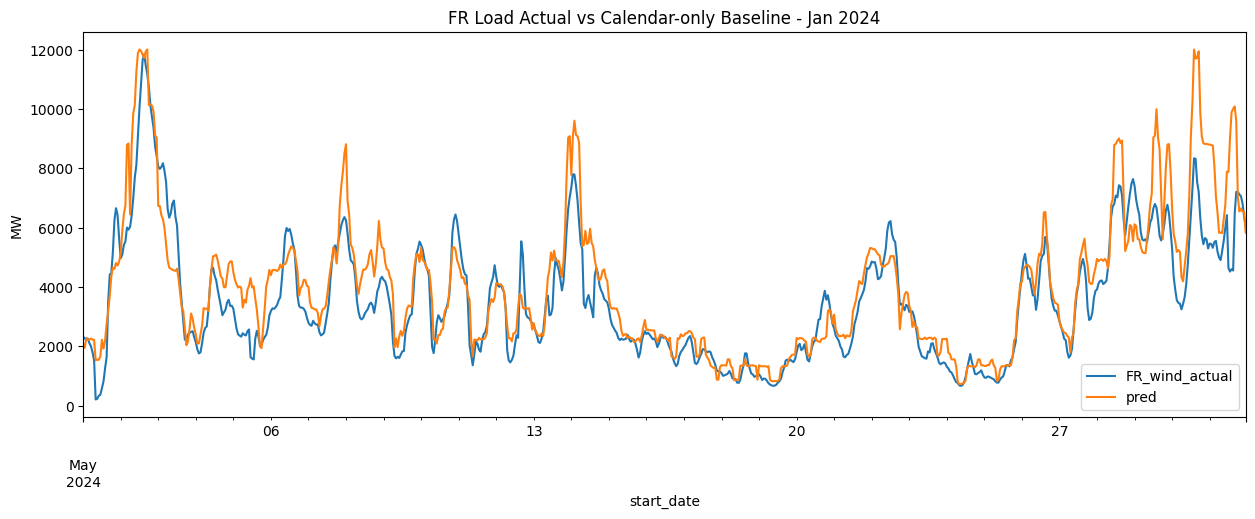

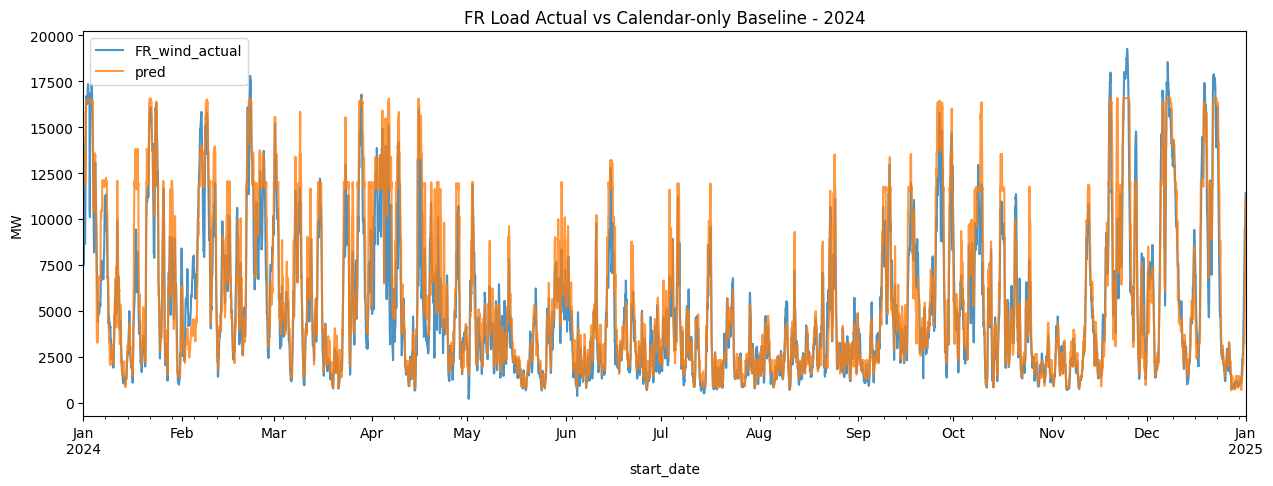

wind_avg            0.948087
FR_capacity_wind    0.030644
doy_sin             0.011197
doy_cos             0.010073
dtype: float64

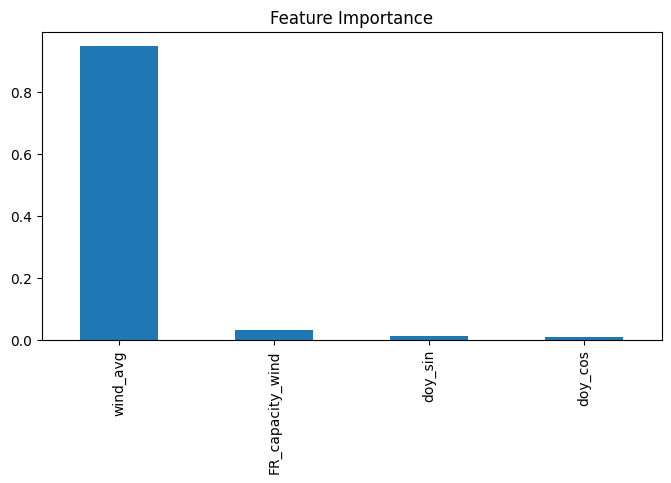

In [ ]:

df["FR_capacity_wind"] = df_network["FR_capacity_wind"]

wind_cols = [
    col for col in df_weather.columns
    if col[2] == "100ws"
]

df["wind_avg"] = df_weather[wind_cols].mean(axis=1)

df["wind_avg"] = (
    df["wind_avg"]
    .interpolate()
    .bfill()
    .ffill()
)



TARGET = "FR_wind_actual"

FEATURES = [
    "FR_capacity_wind",
    "wind_avg",
    "doy_sin",
    "doy_cos",
]


train, valid, model = forecast_model(df, FEATURES, TARGET)

# -------------------------
# 8. Plot one month
# -------------------------

valid.loc["2024-05", [TARGET, "pred"]].plot(figsize=(15, 5))
plt.title("FR Load Actual vs Calendar-only Baseline - Jan 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 9. Plot whole validation year
# -------------------------

valid[[TARGET, "pred"]].plot(figsize=(15, 5), alpha=0.8)
plt.title("FR Load Actual vs Calendar-only Baseline - 2024")
plt.ylabel("MW")
plt.show()


# -------------------------
# 10. Feature importance
# -------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

display(feature_importance)

feature_importance.plot(kind="bar", figsize=(8, 4))
plt.title("Feature Importance")
plt.show()


# MAE:  1,070.33 MW
# RMSE: 1,617.28 MW

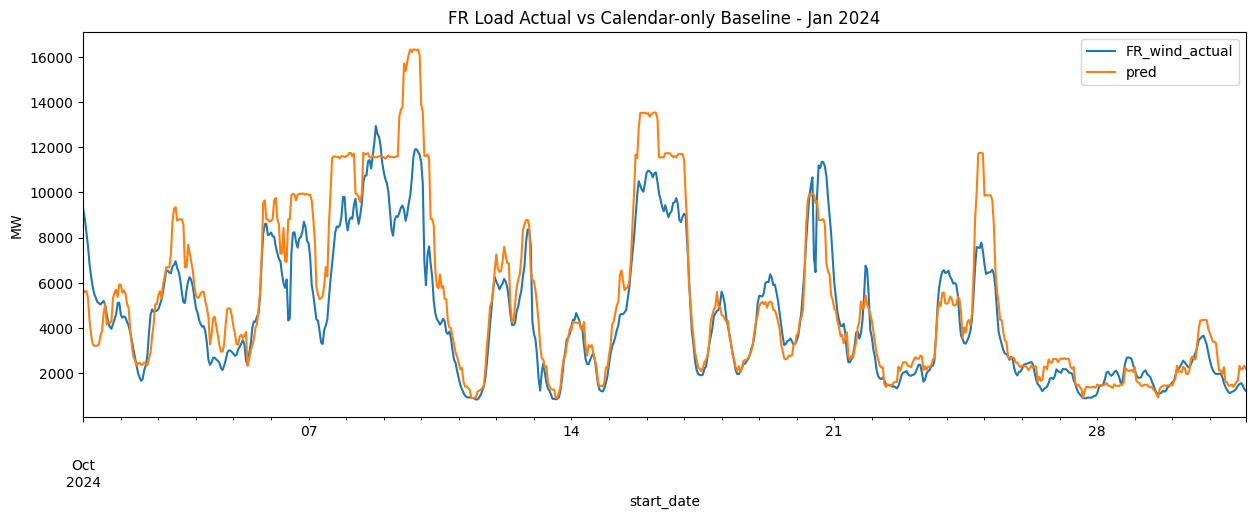

In [143]:
valid.loc["2024-10", [TARGET, "pred"]].plot(figsize=(15, 5))
plt.title("FR Load Actual vs Calendar-only Baseline - Jan 2024")
plt.ylabel("MW")
plt.show()

<Axes: xlabel='start_date'>

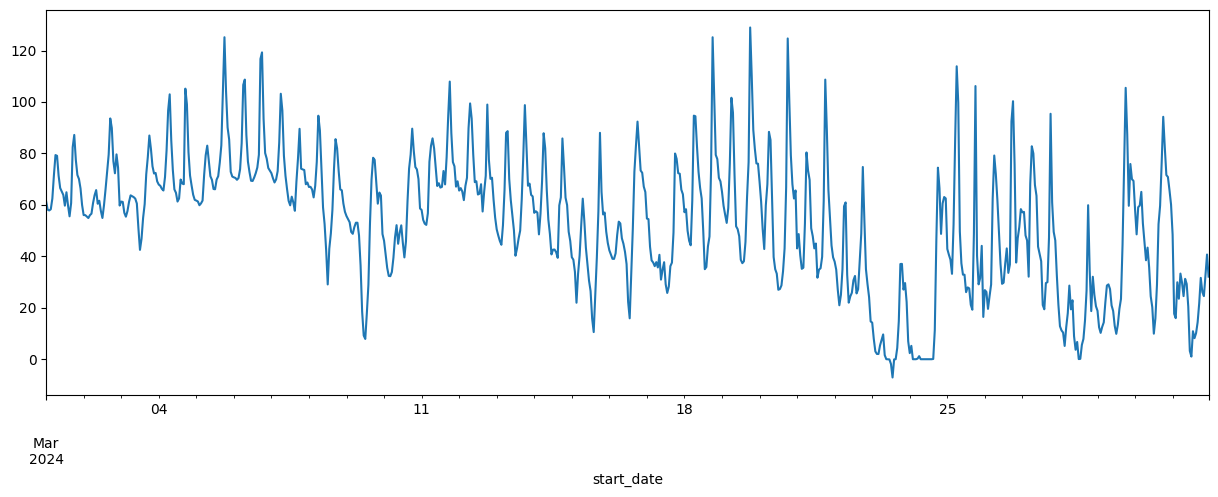

In [175]:
df_target.loc["2024-03", "FR_price_actual"].plot(figsize=(15,5))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3096
[LightGBM] [Info] Number of data points in the train set: 35064, number of used features: 13
[LightGBM] [Info] Start training from score 128.460076
MAE:  24.80 MW
RMSE: 32.36 MW
MAE:  24.80 €/MWh
RMSE: 32.36 €/MWh


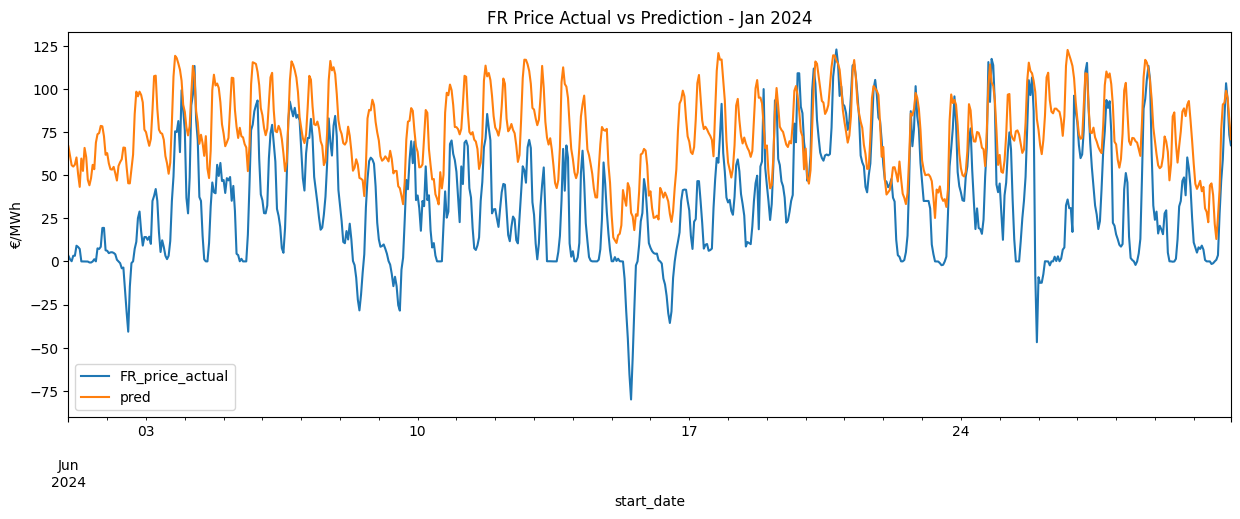

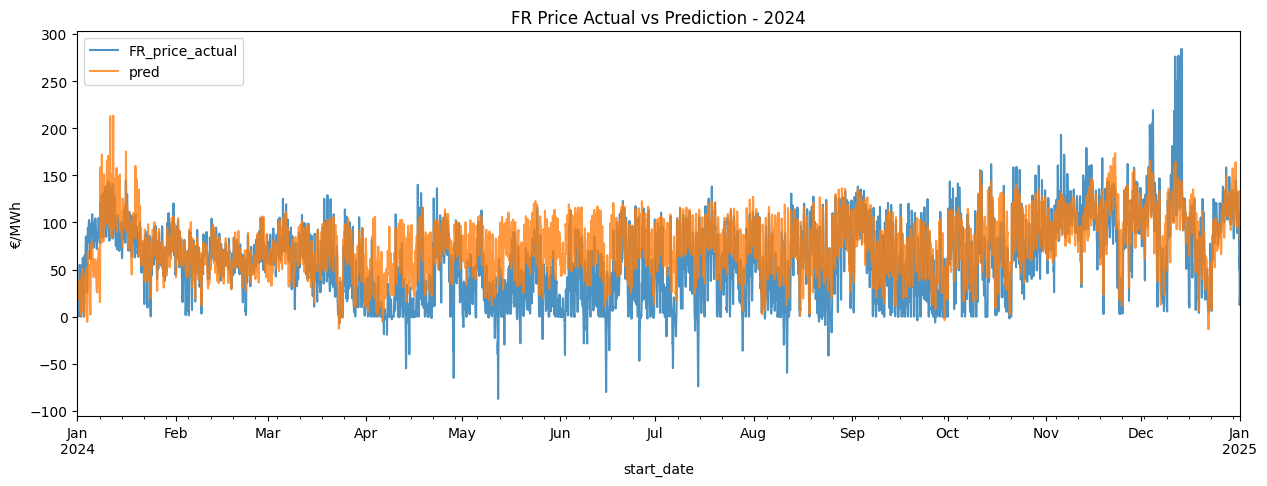

FR_load_actual             4156
temp_avg                   2788
FR_availability_nuclear    2690
doy_sin                    2636
FR_wind_actual             2449
EEX_GAS_PEG                2416
EEX_COAL                   2322
FR_solar_actual            2311
doy_cos                    2304
EEX_CARBON                 1995
FR_availability_gas        1818
FR_availability_hydro      1732
FR_availability_coal        383
dtype: int32

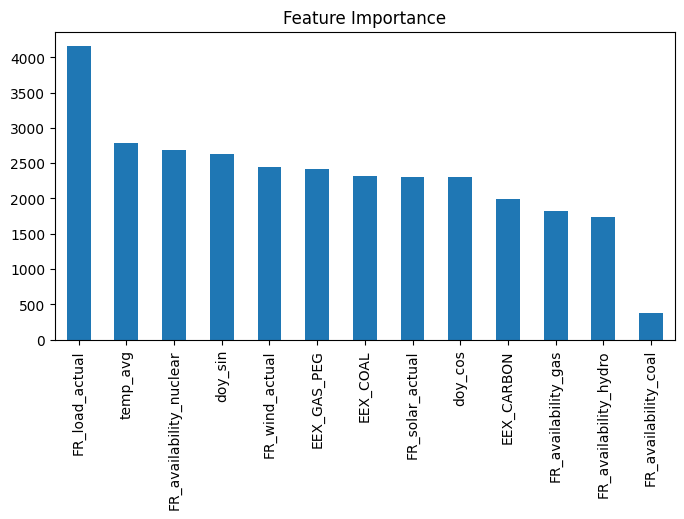

In [236]:


# -------------------------
# 1. Add network features
# -------------------------

network_cols = [
    "EEX_CARBON",
    "EEX_COAL",
    "EEX_GAS_PEG",
    "FR_availability_coal",
    "FR_availability_gas",
    "FR_availability_hydro",
    "FR_availability_nuclear",
]

for col in network_cols:
    df[col] = df_network[col]


# -------------------------
# 2. Define target and features
# -------------------------

TARGET = "FR_price_actual"

FEATURES = [
    "FR_load_actual",
    "FR_solar_actual",
    "FR_wind_actual",
    "doy_cos",
    "doy_sin",
    "EEX_CARBON",
    "EEX_COAL",
    "EEX_GAS_PEG",
    "FR_availability_coal",
    "FR_availability_gas",
    "FR_availability_hydro",
    "FR_availability_nuclear",
    "temp_avg",
]


# -------------------------
# 3. Train model
# -------------------------

train, valid, model = forecast_model(df, FEATURES, TARGET)


# -------------------------
# 4. Evaluate
# -------------------------

mae = mean_absolute_error(
    valid["FR_price_actual"],
    valid["pred"],
)

rmse = mean_squared_error(
    valid["FR_price_actual"],
    valid["pred"],
) ** 0.5

print(f"MAE:  {mae:.2f} €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")


# -------------------------
# 5. Plot one month
# -------------------------

valid.loc["2024-06", ["FR_price_actual", "pred"]].plot(figsize=(15, 5))
plt.title("FR Price Actual vs Prediction - Jan 2024")
plt.ylabel("€/MWh")
plt.show()


# -------------------------
# 6. Plot whole validation year
# -------------------------

valid[["FR_price_actual", "pred"]].plot(figsize=(15, 5), alpha=0.8)
plt.title("FR Price Actual vs Prediction - 2024")
plt.ylabel("€/MWh")
plt.show()


# -------------------------
# 7. Feature importance
# -------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=FEATURES,
).sort_values(ascending=False)

display(feature_importance)

feature_importance.plot(kind="bar", figsize=(8, 4))
plt.title("Feature Importance")
plt.show()

In [258]:
train.loc["2024", ["FR_price_actual", "pred"]].plot(figsize=(15, 5))
plt.title("FR Price Actual vs Prediction")
plt.ylabel("€/MWh")
plt.show()

KeyError: '2024'

<Axes: xlabel='start_date'>

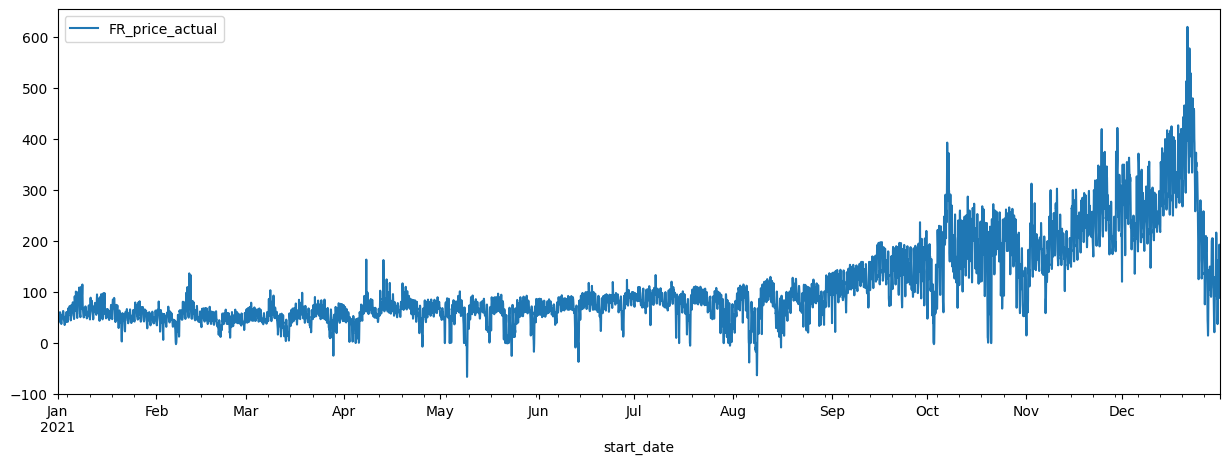

In [254]:
df.loc["2021", ["FR_price_actual"]].plot(figsize=(15, 5))